## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.  

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/vegetation_condition_index/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  


# Vegetation Condition Index

This notebook demonstrates how to calculate the Vegetation Condition Index (VCI) from Sentinel‑2 Normalized Difference Vegetation Index (NDVI) time series using openEO. The script evaluates vegetation status on an **observed date**, defined as the newest available Sentinel‑2 acquisition within the requested temporal extent. It then identifies **historical dates** within a 5‑day window around this observed date and computes the minimum and maximum NDVI over these historical acquisitions, which are subsequently compared to the NDVI on the observed date to derive VCI.

## Pre‑processing Step to Create Cloud-Free Images

The Evalscript includes a pre‑processing step that removes cloudy pixels from Sentinel‑2 scenes acquired for the selected dates. In the reference Evalscript, cloud removal is based on a dedicated cloud mask band (e.g. `CLP`). However, openEO backends such as CDSE do not provide this band directly. As a workaround, we use the Scene Classification Layer (`SCL`) available in the Sentinel‑2 data on CDSE. The following SCL values will be removed to generate a cloud mask and filter out cloudy pixels (reference: [Cloudless Mosaic Script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/)):
- 0 - No data
- 1 - Saturated / defective
- 3 - Cloud shadows
- 8 - Clouds medium probability
- 9 - Clouds high probability
- 10 - Cirrus
- 11 - Snow/ice

## Calculation of Vegetation Condition Index (VCI)

VCI is calculated on cloud-free images as:

\begin{equation*}
\text{VCI} = \frac{\text{NDVI}_{\text{observed}} - \text{NDVI}_{\text{hist,min}}}{\text{NDVI}_{\text{hist,max}} - \text{NDVI}_{\text{hist,min}}}
\end{equation*}

## Overview

In this notebook, we will:
1. Connect to the CDSE openEO backend (https://openeo.dataspace.copernicus.eu/)
2. Define an area of interest containing terrestrial land
3. Create cloud‑free scenes for the selected dates, using SCL band and Braaten-Cohen-Yang cloud detector
4. Calculate NDVI from the cloud‑free scenes
5. Define the observed and historical dates
    - The observed date is the newest available Sentinel‑2 acquisition within the requested time interval
    - Historical dates are all other acquisition dates that fall within a 5‑day window around this observed date
6. Calculate the Vegetation Condition Index (VCI)


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [9]:
import rioxarray
import openeo
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create, if_, and_, neq


## Connect to CDSE backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. The spatial extent below corresponds to Dodge City, Kansas, United States

In [4]:
spatial_extent = {"west": -100.7, "south" : 37.89, "east" : -100.51, "north" : 38.00}

## Load Sentinel-2 Product

In [5]:
# The initial time range to evaluate data availability and their acquisition dates
broad_time_range = ["2020-05-20", "2020-05-22"]

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=broad_time_range,
    bands=["B03", "B04", "B08", "SCL"]
)

In [6]:
# Exclude 0, 1, 3, 8, 9, 10, 11
def remove_cloud(scl_band):
    return and_(
        neq(scl_band, 3),
        and_(
            neq(scl_band, 9),
            and_(
                neq(scl_band, 8),
                and_(
                    neq(scl_band, 10),
                    and_(
                        neq(scl_band, 11),
                        and_(
                            neq(scl_band, 1),
                            neq(scl_band, 0)
                        )
                    )
                )
            )
        )
    )

In [7]:
def ndvi_calculation(data):
    B03, B04, B08, SCL = (
        data[0],
        data[1],
        data[2],
        data[3]
    )

    # Scale CDSE integer data to reflectance [0, 1]
    B03 = B03 / 10000
    B04 = B04 / 10000
    B08 = B08 / 10000

    # Algorithm to create clear, cloud-less images
    is_not_cloud = remove_cloud(SCL)

    result = array_create([
        if_(is_not_cloud, B03, None),
        if_(is_not_cloud, B04, None),
        if_(is_not_cloud, B08, None)
    ])

    # TODO: Continue with NDVI calculation
    
    return result

In [ ]:
# Running this only to test if the cloud masking algorithm works well
cloud_free = s2cube.apply_dimension(
    dimension="bands",
    process=ndvi_calculation
)

# Cloud-free image on the observed date
cloud_free = cloud_free.reduce_dimension(dimension="t", reducer="last")

# TODO: Continue with NDVI calculation: NDVI on the observed date, NDVI max and min across timeseries

# TODO: Calculate VCI

cloud_free = cloud_free.save_result("GTiff")
cloud_free.download("cloud_free_observed_date_cdse.tif")

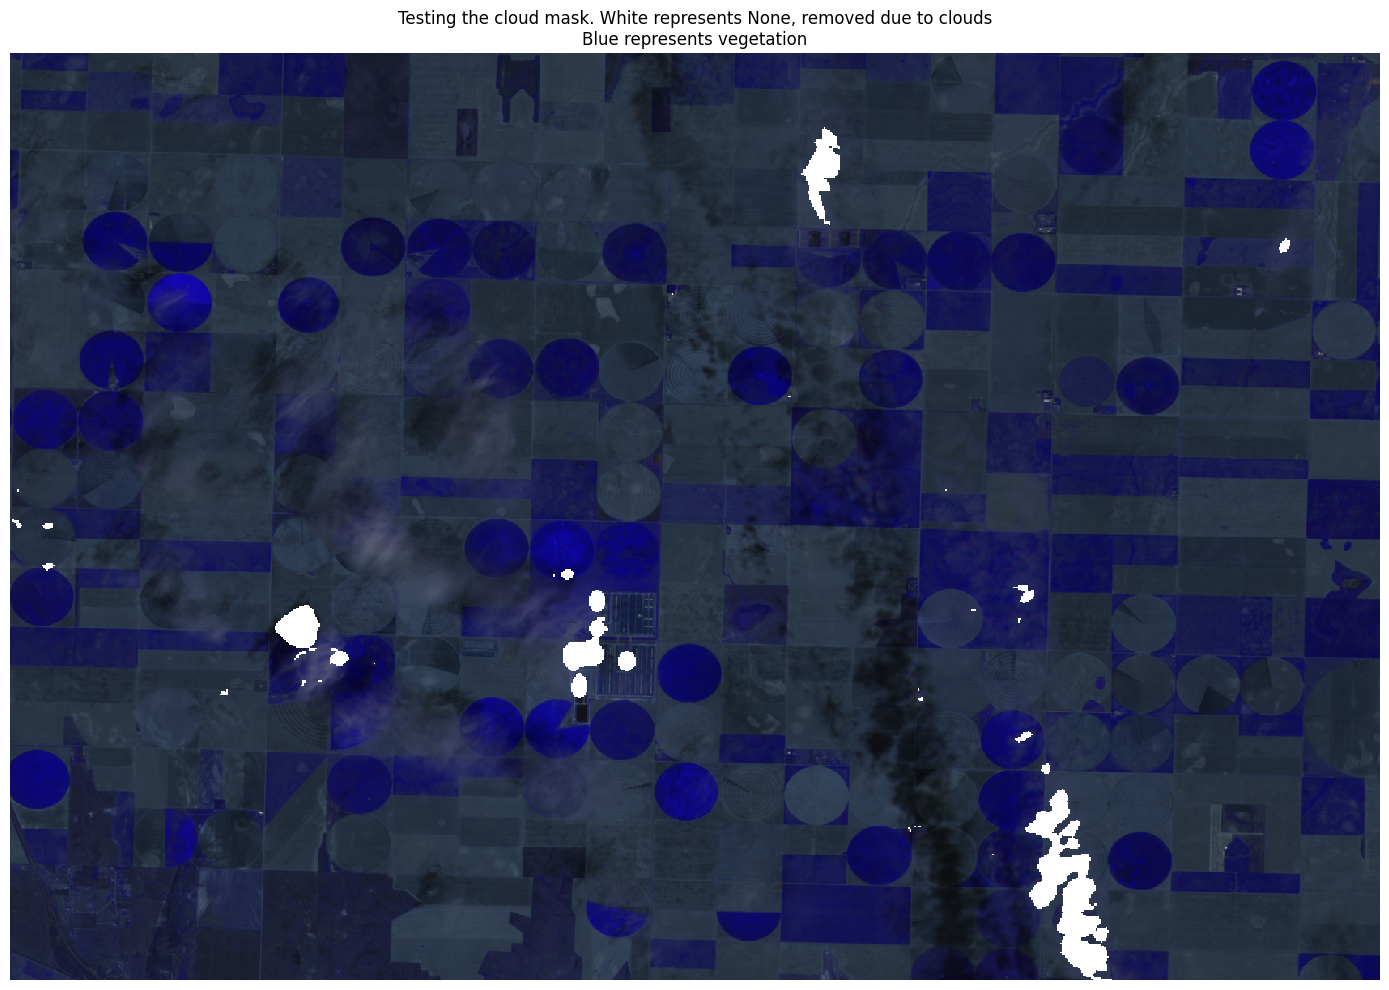

In [ ]:
ds = rioxarray.open_rasterio("cloud_free_observed_date_cdse.tif")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ds.sel(band=[1,2,3]).plot.imshow(ax=ax)
ax.set_title(
    "Testing the cloud mask. White represents None, removed due to clouds\n"
    "Blue represents vegetation",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()